In [151]:
import re
import time
import requests
import warnings
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')

In [152]:
df=pd.read_csv('scrapped_data.csv')

In [153]:
df.head()

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,Lenovo IdeaPad Slim 5 OLED Display Intel Core ...,"₹1,39,990","₹2,30,290",39% off,4.2,15 Ratings&1 Reviews,Intel Core Ultra 9 Processor 16 GB DDR5 RAM Wi...,1
1,MOTOROLA Motobook 60 Full Metal WUXGA OLED (i5...,"₹66,990","₹1,35,000",50% off,4.4,"3,885 Ratings&509 Reviews",Intel Core 5 Processor 16 GB DDR5 RAM 64 bit W...,1
2,Lenovo 100e Chromebook Gen 4 MediaTek Kompanio...,"₹22,544","₹25,999",13% off,4.0,"3,712 Ratings&361 Reviews",MediaTek Kompanio 520 Processor 4 GB LPDDR4X R...,1
3,Acer Aspire Lite Metal (2026) AMD Ryzen 3 Quad...,"₹36,990","₹52,990",30% off,4.1,"1,015 Ratings&105 Reviews",AMD Ryzen 3 Quad Core Processor 8 GB DDR4 RAM ...,1
4,Ultimus Elite Intel Core i5 10th Gen 1035G4 - ...,"₹45,990",NaN,NaN,3.6,542 Ratings&135 Reviews,Intel Core i5 Processor (10th Gen) 8 GB DDR4 R...,1


In [154]:
df.dtypes

Product Name       object
Price              object
Original Price     object
Discount           object
Rating            float64
Reviews            object
Features           object
Page Number         int64
dtype: object

In [155]:
df.columns = df.columns.str.lower() #columns names are changing to lower case

In [156]:
df.rename({'product name':"product_name",'original price':'original_price'},axis=1,inplace=True) #renaming the column names

In [157]:
df['Brands'] = df['product_name'].apply(lambda x:re.findall(r"\w+",x)[0]) #extracting brands

In [158]:
df['Brands'].value_counts() #checking extracted Brands column

Brands
ASUS          322
HP            160
MOTOROLA      127
Acer          109
Lenovo        107
DELL           81
MSI            29
Apple          12
Infinix         9
Samsung         8
Primebook       4
Prittec         3
Thomson         3
WarnerCann      2
GIGABYTE        2
MICROSOFT       2
Avita           2
Ultimus         1
WINGS           1
Name: count, dtype: int64

In [159]:
#extracting Processor
def extract_processor(text):
    text = str(text)
    # Special format: Processor: Intel i5-1235U ...
    match = re.search(
        r'Processor:\s*(Intel\s+i5-\d+[A-Za-z]*)',
        text,
        flags=re.IGNORECASE
    )
    if match:
        return match.group(1).strip()
    # Normal format: Intel Core i5 Processor ...
    match = re.search(
        r'(.+?)\s*Processor',
        text,
        flags=re.IGNORECASE
    )
    return match.group(1).strip() if match else np.nan
    
df['Processor'] = df['features'].apply(extract_processor)

In [160]:
df['Processor'].value_counts().head(20) #checking 'Processor' extracted column

Processor
Intel Core 5               157
Intel Core i5              147
Intel Core 3               126
Intel Core Ultra 5         108
Intel Core i3               82
Intel Core i7               74
AMD Ryzen 3 Quad Core       48
AMD Ryzen 5 Hexa Core       37
Intel Celeron Dual Core     27
AMD Ryzen 7 Octa Core       21
Intel Core Ultra 7          19
Snapdragon X                17
AMD Ryzen 5 Quad Core       14
Intel Core Ultra 9          14
AMD Athlon Dual Core        10
AMD Ryzen 7                  9
AMD Ryzen 3                  8
Intel Core 7                 7
AMD Ryzen 5                  5
AMD Ryzen 3 Dual Core        4
Name: count, dtype: int64

In [161]:
df['Price_rupee'] = df['price'].apply(lambda x:re.sub(r'[₹,]','',x) if isinstance(x,str) else x).astype('UInt32') #extracting price

In [162]:
df['Price_rupee'].isnull().sum() #checking extracted column

np.int64(8)

In [163]:
df['Discount_pct'] = df['discount'].apply(lambda x:re.findall(r'\d+',x)[0] if isinstance(x,str) else x).astype('UInt8') #extracting discount

In [164]:
df[['discount', 'Discount_pct']].head(10) #checking if it extracting correct or not

,discount,Discount_pct
0,39% off,39
1,50% off,50
2,13% off,13
3,30% off,30
4,NaN,<NA>
5,NaN,<NA>
6,28% off,28
7,4% off,4
8,7% off,7
9,NaN,<NA>


In [165]:
df['Total_Ratings'] = df['reviews'].apply(lambda x:re.findall(r'[0-9,]+',x)[0] if isinstance(x,str) else x).str.replace(',','').astype('UInt16') #Total rating given extracitng

In [166]:
df[['reviews', 'Total_Ratings']].head(10) #checking if it extracting correct or not

,reviews,Total_Ratings
0,15 Ratings&1 Reviews,15
1,"3,885 Ratings&509 Reviews",3885
2,"3,712 Ratings&361 Reviews",3712
3,"1,015 Ratings&105 Reviews",1015
4,542 Ratings&135 Reviews,542
5,117 Ratings&17 Reviews,117
6,19 Ratings&1 Reviews,19
7,386 Ratings&38 Reviews,386
8,NaN,<NA>
9,329 Ratings&53 Reviews,329


In [167]:
df['gb_list'] = df['features'].apply(lambda x:re.findall(r"\d+\s*GB",x) if isinstance(x,str) else x) #extracts RAM,SSD
df['RAM'] = df['gb_list'].apply(lambda x:x[0] if len(x)>0 else np.nan)                 #extracts RAM with GB
df['RAM_gb']=df['RAM'].str.extract(r'(\d+)').astype('UInt16')                          #extracts RAM with no GB

In [168]:
df[['features', 'gb_list', 'RAM', 'RAM_gb']].head(10) #checking if it extracting correct or not

,features,gb_list,RAM,RAM_gb
0,Intel Core Ultra 9 Processor 16 GB DDR5 RAM Wi...,"[16 GB, 512 GB]",16 GB,16
1,Intel Core 5 Processor 16 GB DDR5 RAM 64 bit W...,"[16 GB, 512 GB]",16 GB,16
2,MediaTek Kompanio 520 Processor 4 GB LPDDR4X R...,[4 GB],4 GB,4
3,AMD Ryzen 3 Quad Core Processor 8 GB DDR4 RAM ...,"[8 GB, 256 GB]",8 GB,8
4,Intel Core i5 Processor (10th Gen) 8 GB DDR4 R...,"[8 GB, 512 GB]",8 GB,8
5,Intel Core i7 Processor (13th Gen) 16 GB DDR5 ...,"[16 GB, 512 GB]",16 GB,16
6,Intel Core N Processor (12th Gen) 12 GB DDR4 R...,"[12 GB, 256 GB]",12 GB,12
7,AMD Athlon Dual Core Processor 8 GB DDR4 RAM 6...,"[8 GB, 256 GB]",8 GB,8
8,Intel Pentium Quad Core Processor 8 GB DDR4 RA...,"[8 GB, 256 GB]",8 GB,8
9,Intel Celeron Dual Core Processor 4 GB LPDDR5 ...,[4 GB],4 GB,4


In [169]:
df['SSD'] = df['features'].apply(
    lambda x: re.findall(r'(\d+(?:\.\d+)?)\s*(GB|TB)\s*SSD', x, flags=re.IGNORECASE)[0]
    if re.findall(r'(\d+(?:\.\d+)?)\s*(GB|TB)\s*SSD', x, flags=re.IGNORECASE)
    else np.nan
)               #extracts SSD with GB
df['SSD_gb'] = df['SSD'].apply(
    lambda x: int(float(x[0]) * 1024) if isinstance(x, tuple) and x[1].upper() == 'TB'
    else int(float(x[0])) if isinstance(x, tuple)
    else np.nan
).astype('UInt16')                  #extracts SSD with no GB

In [170]:
df[['features', 'SSD', 'SSD_gb']].head(20) #checking if it extracting correct or not

,features,SSD,SSD_gb
0,Intel Core Ultra 9 Processor 16 GB DDR5 RAM Wi...,"(512, GB)",512
1,Intel Core 5 Processor 16 GB DDR5 RAM 64 bit W...,"(512, GB)",512
2,MediaTek Kompanio 520 Processor 4 GB LPDDR4X R...,NaN,<NA>
3,AMD Ryzen 3 Quad Core Processor 8 GB DDR4 RAM ...,"(256, GB)",256
4,Intel Core i5 Processor (10th Gen) 8 GB DDR4 R...,"(512, GB)",512
5,Intel Core i7 Processor (13th Gen) 16 GB DDR5 ...,"(512, GB)",512
6,Intel Core N Processor (12th Gen) 12 GB DDR4 R...,"(256, GB)",256
7,AMD Athlon Dual Core Processor 8 GB DDR4 RAM 6...,"(256, GB)",256
8,Intel Pentium Quad Core Processor 8 GB DDR4 RA...,"(256, GB)",256
9,Intel Celeron Dual Core Processor 4 GB LPDDR5 ...,NaN,<NA>


In [175]:
df['Display_cm'] = df['features'].apply(
    lambda x: round(float(re.findall(r'(\d+(?:\.\d+)?)\s*cm', str(x))[0]), 1)
    if re.findall(r'(\d+(?:\.\d+)?)\s*cm', str(x))
    else np.nan
)

In [176]:
df[['features', 'Display_cm']].head(10) #checking extraction

,features,Display_cm
0,Intel Core Ultra 9 Processor 16 GB DDR5 RAM Wi...,35.6
1,Intel Core 5 Processor 16 GB DDR5 RAM 64 bit W...,35.6
2,MediaTek Kompanio 520 Processor 4 GB LPDDR4X R...,29.5
3,AMD Ryzen 3 Quad Core Processor 8 GB DDR4 RAM ...,39.6
4,Intel Core i5 Processor (10th Gen) 8 GB DDR4 R...,35.8
5,Intel Core i7 Processor (13th Gen) 16 GB DDR5 ...,39.6
6,Intel Core N Processor (12th Gen) 12 GB DDR4 R...,38.9
7,AMD Athlon Dual Core Processor 8 GB DDR4 RAM 6...,39.6
8,Intel Pentium Quad Core Processor 8 GB DDR4 RA...,35.6
9,Intel Celeron Dual Core Processor 4 GB LPDDR5 ...,39.6


In [185]:
df.loc[(df['Display_cm'] < 25) | (df['Display_cm'] > 50), 'Display_cm'] = np.nan = np.nan #making blank for display<25 or >50

In [188]:
df['Display_cm'].isna().sum()

np.int64(4)

In [189]:
df.rename({'Brands':'Brand'},axis=1,inplace=True)

In [190]:
df.rename({'rating':'Rating'},axis=1,inplace=True)

In [191]:
df=df[['Brand','Processor','RAM_gb','SSD_gb','Display_cm','Price_rupee','Discount_pct','Rating']]

In [192]:
df.head()

,Brand,Processor,RAM_gb,SSD_gb,Display_cm,Price_rupee,Discount_pct,Rating
0,Lenovo,Intel Core Ultra 9,16,512,35.6,139990,39,4.2
1,MOTOROLA,Intel Core 5,16,512,35.6,66990,50,4.4
2,Lenovo,MediaTek Kompanio 520,4,<NA>,29.5,22544,13,4.0
3,Acer,AMD Ryzen 3 Quad Core,8,256,39.6,36990,30,4.1
4,Ultimus,Intel Core i5,8,512,35.8,45990,<NA>,3.6


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         984 non-null    object 
 1   Processor     984 non-null    object 
 2   RAM_gb        984 non-null    UInt16 
 3   SSD_gb        954 non-null    UInt16 
 4   Display_cm    980 non-null    float64
 5   Price_rupee   976 non-null    UInt32 
 6   Discount_pct  762 non-null    UInt8  
 7   Rating        809 non-null    float64
dtypes: UInt16(2), UInt32(1), UInt8(1), float64(2), object(2)
memory usage: 43.4+ KB


In [194]:
df.describe()

,RAM_gb,SSD_gb,Display_cm,Price_rupee,Discount_pct,Rating
count,984.0,954.0,980.000000,976.0,762.0,809.000000
mean,14.45122,550.930818,37.824184,87097.543033,24.753281,4.229295
std,6.189255,182.147011,2.332424,56903.525251,16.530449,0.358862
min,4.0,32.0,29.500000,16990.0,1.0,1.000000
25%,8.0,512.0,35.600000,58990.0,10.0,4.200000
50%,16.0,512.0,39.600000,69990.0,22.0,4.300000
75%,16.0,512.0,39.600000,92990.0,40.0,4.400000
max,48.0,2048.0,43.200000,619900.0,61.0,5.000000


## DUPLICATES CHECK

In [195]:
df.duplicated().sum()

np.int64(426)

In [196]:
df.drop_duplicates().shape

(558, 8)

In [198]:
df[df.duplicated(keep=False)].sort_values(
    by=['Brand', 'Processor']
).head(20) #checked if they are actually duplicates

,Brand,Processor,RAM_gb,SSD_gb,Display_cm,Price_rupee,Discount_pct,Rating
187,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
211,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
231,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
331,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
377,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
427,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
521,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3
575,ASUS,AMD Ryzen 3 Quad Core,8,512,39.6,57413,3,NaN
589,ASUS,AMD Ryzen 3 Quad Core,8,512,39.6,57413,3,NaN
591,ASUS,AMD Ryzen 3 Quad Core,16,512,39.6,58990,35,4.3


In [205]:
df.drop_duplicates(keep='first', inplace=True, ignore_index=False)

In [206]:
df.shape

(558, 8)

## Handle missing values 

In [207]:
# checking columns where nulls are present visually
df.isna().sum()

Brand             0
Processor         0
RAM_gb            0
SSD_gb           26
Display_cm        4
Price_rupee       8
Discount_pct    119
Rating           95
dtype: int64

#### 1)SSD_gb 
raw_df = pd.read_csv('scrapped_data.csv')
raw_df.loc[df.index[df['SSD_gb'].isna()], ['Product Name', 'Features']] 
- doesnt contain an SSD specification
- so not filling these 26 missing SSD values with 0, mean, or median. keeping nans only

In [215]:
raw_df.loc[df.index[df['Display_cm'].isna()], ['Product Name', 'Features']]

,Product Name,Features
609,HP Envy13 x360 bf0121tu Intel Core i5 12th Gen...,Intel Core i5 Processor (12th Gen) 16 GB LPDDR...
904,Acer Aspire 15 AMD Ryzen 5 Hexa Core - (16 GB/...,AMD Ryzen 5 Hexa Core Processor 16 GB DDR4 RAM...
938,Acer Aspire 5 15 Intel Core i3 13th Gen - (8 G...,Intel Core i3 Processor (13th Gen) 8 GB LPDDR5...
942,Acer Swift Neo OLED AI PC Intel Core Ultra 5 -...,Intel Core Ultra 5 Processor 16 GB LPDDR5 RAM ...


#### 2)Display_cm
- these are not genuinely missing values; they are bad source values that we intentionally converted to NaN
- So we are keeping these also Nan only

#### 3) Price_rupee
 raw_df.loc[df.index[df['Price_rupee'].isna()], ['Product Name', 'Price']]
- these 8 products genuinely have no price available in the scraped data.
- removed these 8 rows from the dataset.

In [219]:
df.dropna(subset=['Price_rupee'], inplace=True)

In [221]:
df.shape #total rows and columns in df after 8 rows removed

(550, 8)

In [223]:
df['Price_rupee'].isna().sum() #checking

np.int64(0)

#### 4) Discount_pct
 raw_df.loc[df.index[df['Discount_pct'].isna()], ['Product Name', 'Price', 'Discount']]
- have no discount information in the scraped data.
- NaN means discount information wasn't available.
- 0 means we know there was no discount.
- We don't have enough evidence to make that assumption.
- Filling with mean/median would also be inappropriate for a percentage discount.
- Keeping the 111 missing values as NaN.

#### 5) Rating
raw_df.loc[df.index[df['Rating'].isna()], ['Product Name', 'Rating', 'Reviews']]
- 0 → because 0 would mean a rating of zero.
- Mean rating → because that would invent ratings for products with no ratings.
- Median rating → same problem.
- keeping these 93 values as NaN

In [226]:
df.isna().sum()

Brand             0
Processor         0
RAM_gb            0
SSD_gb           26
Display_cm        4
Price_rupee       0
Discount_pct    111
Rating           93
dtype: int64

In [229]:
df.reset_index(drop=True, inplace=True)

## Handling Outliers:



#### 1)Calculating the price outlier limits
- There are 34 price outliers according to the IQR rule
- These look like legitimate premium laptops, not data-entry errors.
- So we are NOT removing or changing anything in these rows.


In [244]:
Q1 = df['Price_rupee'].quantile(0.25)
Q3 = df['Price_rupee'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)  #no records at this limit
print("Upper Limit:", upper_limit)
# outliers = df[(df['Price_rupee'] < lower_limit) |(df['Price_rupee'] > upper_limit)]
# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee']]

Q1: 55990.0
Q3: 91990.0
IQR: 36000.0
Lower Limit: 1990.0
Upper Limit: 145990.0


#### 2)Calculating the RAM outlier limits
- All 23 outliers are 32 GB or 48 GB.
- There are 0 lower outliers, because the lowest RAM is 4 GB and our lower limit is -4 GB.
- So,keeping all 23 RAM outliers.

In [247]:
Q1 = df['RAM_gb'].quantile(0.25)
Q3 = df['RAM_gb'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[(df['RAM_gb'] < lower_limit) |(df['RAM_gb'] > upper_limit)]
print("Total outliers:", len(outliers))
# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee']]


Q1: 8.0
Q3: 16.0
IQR: 8.0
Lower Limit: -4.0
Upper Limit: 28.0
Total outliers: 23


#### 3)Calculating the SSD_gb outlier limits
- IQR=0, the outliers we get are not wrong values
- 32, 128, 256, 512, 1024 and 2048 GB can all be legitimate laptop storage capacities so we are keeping these outliers
- No removing these 103 outliers or change keping them all

In [250]:
Q1 = df['SSD_gb'].quantile(0.25)
Q3 = df['SSD_gb'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df['SSD_gb'] < lower_limit) |
    (df['SSD_gb'] > upper_limit)
]

print("Total outliers:", len(outliers))

# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee']]

Q1: 512
Q3: 512
IQR: 0
Lower Limit: 512.0
Upper Limit: 512.0
Total outliers: 103


#### 4)Calculating the Display_cm outlier limits
- 13 outliers are 29.5 cm
- These are not data errors.
- A 29.5 cm display is approximately 11.6 inches, which is a legitimate laptop/netbook/Chromebook display size.
- No changes done to the dataset. Keeping all 13 values of 29.5 cm.

In [254]:
Q1 = df['Display_cm'].quantile(0.25)
Q3 = df['Display_cm'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df['Display_cm'] < lower_limit) |
    (df['Display_cm'] > upper_limit)
]

print("Total outliers:", len(outliers))

# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee']]

Q1: 35.6
Q3: 39.6
IQR: 4.0
Lower Limit: 29.6
Upper Limit: 45.6
Total outliers: 13


#### 5)Calculating the Discount_pct outlier limits
- All 9 outliers are above 46%, ranging from 47% to 61%.
- These discounts are completely possible in an e-commerce dataset
- No changes done to the dataset

In [257]:
Q1 = df['Discount_pct'].quantile(0.25)
Q3 = df['Discount_pct'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df['Discount_pct'] < lower_limit) |
    (df['Discount_pct'] > upper_limit)
]

print("Total outliers:", len(outliers))

# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee', 'Discount_pct']]

Q1: 6
Q3: 22
IQR: 16
Lower Limit: -18.0
Upper Limit: 46.0
Total outliers: 9


#### 6)Calculating the Rating outlier limits
- The 42 outliers consist of ratings below 3.65 and ratings above 4.85.
- It id possible to have these ratings
- So nothing removes or changed

In [259]:
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df['Rating'] < lower_limit) |
    (df['Rating'] > upper_limit)
]

# print("Total outliers:", len(outliers))

# outliers[['Brand', 'Processor', 'RAM_gb', 'SSD_gb', 'Display_cm', 'Price_rupee', 'Rating']]

Q1: 4.1
Q3: 4.4
IQR: 0.3000000000000007
Lower Limit: 3.6499999999999986
Upper Limit: 4.850000000000001


In [322]:
df.to_csv('Final_Cleaned_Dataset.csv',index=False) # Saving CLEANED DATASET FOR ANAlysis

In [323]:
df=pd.read_csv('Final_Cleaned_Dataset.csv')  #opening and use cleaned dataset for analaysis

In [324]:
df.shape

(550, 8)

In [325]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         550 non-null    object 
 1   Processor     550 non-null    object 
 2   RAM_gb        550 non-null    int64  
 3   SSD_gb        524 non-null    float64
 4   Display_cm    546 non-null    float64
 5   Price_rupee   550 non-null    int64  
 6   Discount_pct  439 non-null    float64
 7   Rating        457 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 34.5+ KB


## Questions vs Analysis vs Insights

### Question 1: Which laptop brands have the highest number of products in the Laptop Market?

In [396]:
brand_counts = df['Brand'].value_counts() #Univariate Analysis
brand_counts

Brand
ASUS          143
HP            141
Acer          103
Lenovo         56
DELL           34
MSI            27
Apple           9
Samsung         8
Infinix         8
Prittec         3
MOTOROLA        3
Primebook       3
WarnerCann      2
GIGABYTE        2
Thomson         2
MICROSOFT       2
Avita           2
Ultimus         1
WINGS           1
Name: count, dtype: int64

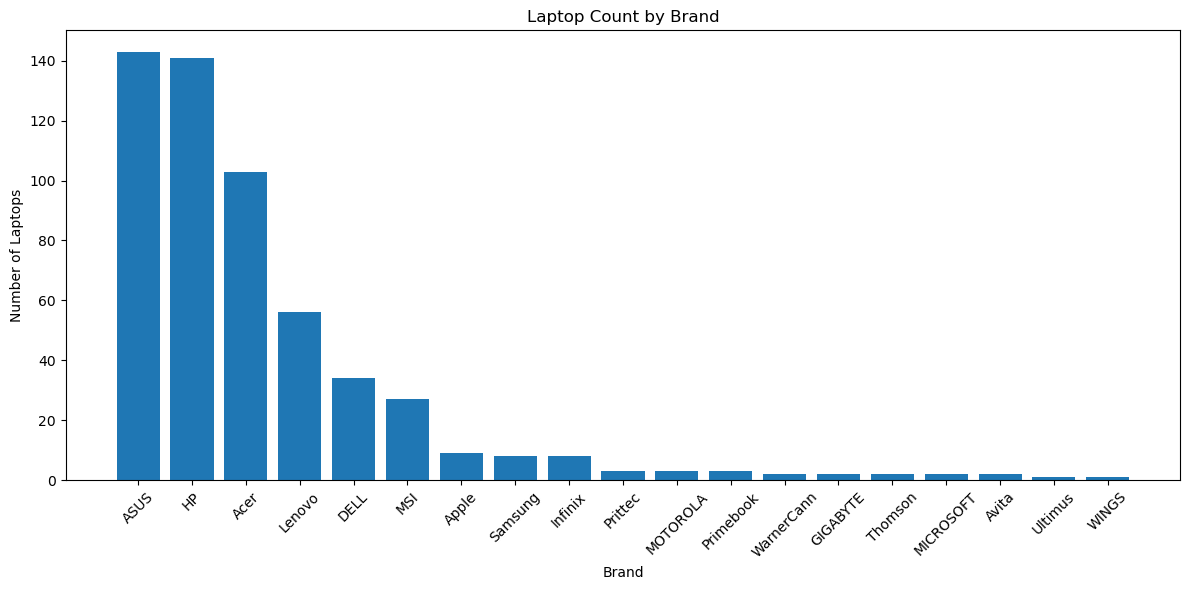

In [397]:
plt.figure(figsize=(12, 6))

plt.bar(brand_counts.index, brand_counts.values)

plt.title('Laptop Count by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('brand_counts.png', transparent=True)
plt.show()

### Answer:
ASUS has the highest number of laptops in the scraped dataset with 143 products, closely followed by HP with 141 products and Acer with 103 products. These three brands account for approximately 70% of the cleaned dataset, indicating that they have the strongest representation in the scraped laptop listings.

### Observation:
The scraped laptop market is highly concentrated among ASUS, HP, and Acer, while the remaining brands have considerably fewer listings.

### Question 2: Which processor types are most commonly available?

In [329]:
processor_counts = df['Processor'].value_counts()
processor_counts

Processor
Intel Core i5                     130
Intel Core i3                      71
Intel Core i7                      38
AMD Ryzen 5 Hexa Core              33
Intel Core Ultra 5                 29
AMD Ryzen 3 Quad Core              29
Intel Celeron Dual Core            27
Intel Core 3                       24
AMD Ryzen 7 Octa Core              20
Intel Core 5                       20
Intel Core Ultra 7                 18
Snapdragon X                       16
AMD Ryzen 5 Quad Core              13
AMD Ryzen 3                         8
AMD Ryzen 7                         7
AMD Athlon Dual Core                6
Intel Core 7                        6
AMD Ryzen 3 Dual Core               4
Intel Core Ultra 9                  4
AMD Ryzen 5                         4
Intel Core i9                       3
AMD Ryzen AI 5 Quad Core            3
Apple M3                            3
Apple M5 Pro                        2
AMD Ryzen 7 Hexa Core               2
Snapdragon X Plus                   2
AM

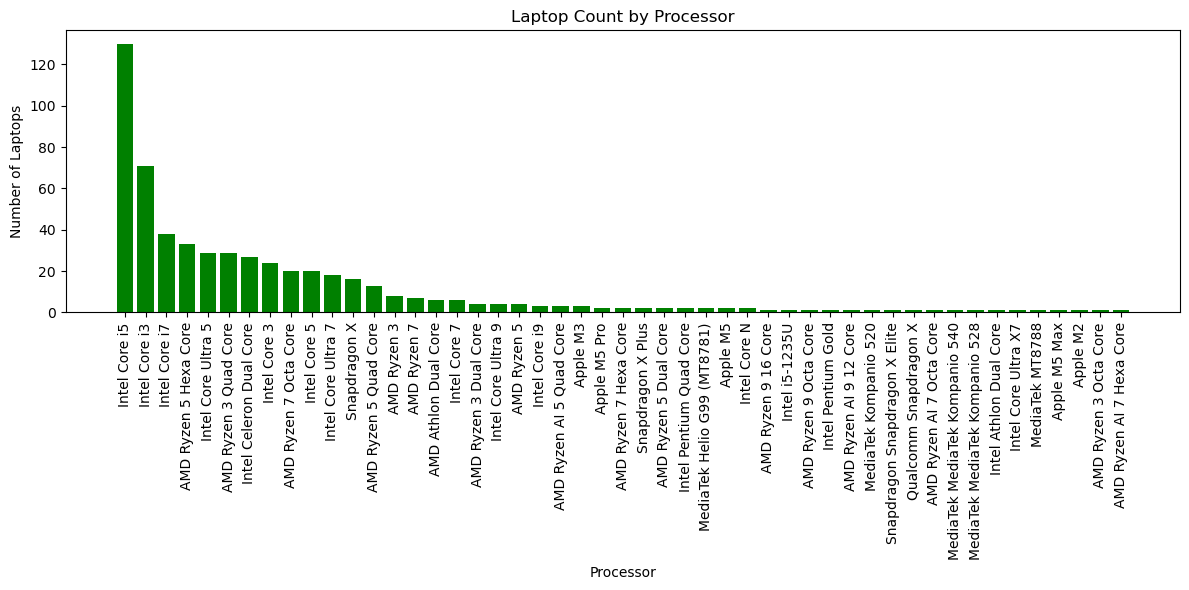

In [330]:
plt.figure(figsize=(12, 6))

plt.bar(processor_counts.index, processor_counts.values,color='green') #Univariate Analyis

plt.title('Laptop Count by Processor')
plt.xlabel('Processor')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig('processor_counts.png', transparent=True)
plt.show()

### Answer:
Intel Core i5 is the most commonly available processor in the scraped dataset, with 130 laptops, followed by Intel Core i3 with 71 laptops and Intel Core i7 with 38 laptops.

### Observation:
The dataset is strongly dominated by Intel processors, particularly the Core i5, Core i3, and Core i7 series. AMD Ryzen processors also have a significant presence, especially Ryzen 5 Hexa Core (33) and Ryzen 3 Quad Core (29).

### Question 3: How are laptops distributed across different RAM capacities?

In [331]:
ram_counts = df['RAM_gb'].value_counts().sort_index()
ram_counts

RAM_gb
4      19
8     211
12     12
16    279
24      6
32     21
48      2
Name: count, dtype: int64

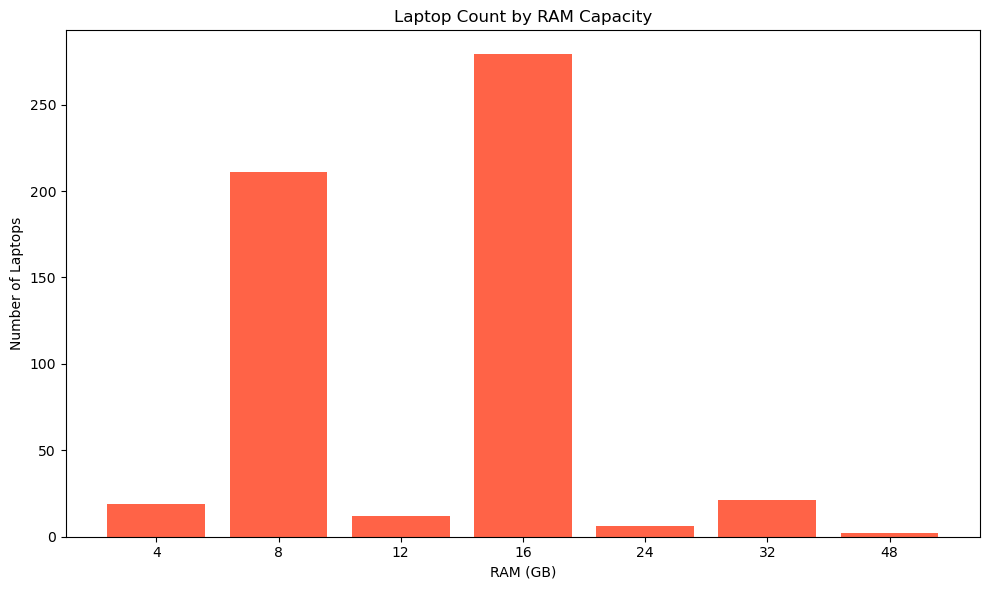

In [332]:
plt.figure(figsize=(10, 6))

plt.bar(ram_counts.index.astype(str), ram_counts.values,color='tomato') #Univariate Analysis

plt.title('Laptop Count by RAM Capacity')
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Laptops')

plt.tight_layout()

plt.savefig('ram_counts.png', transparent=True)

plt.show()

### Answer:
16 GB RAM is the most common configuration, with 279 laptops, followed by 8 GB RAM with 211 laptops. The remaining configurations have much fewer listings.

### Observation:
The dataset is mainly concentrated around 8 GB and 16 GB RAM, with 16 GB being the dominant configuration. Higher capacities such as 32 GB and 48 GB are relatively uncommon.

### Question 4: How are laptops distributed across different SSD capacities?

In [333]:
ssd_counts = df['SSD_gb'].astype('UInt64').value_counts().sort_index()
ssd_counts

SSD_gb
32        1
256      32
500       1
512     421
1024     65
2048      4
Name: count, dtype: Int64

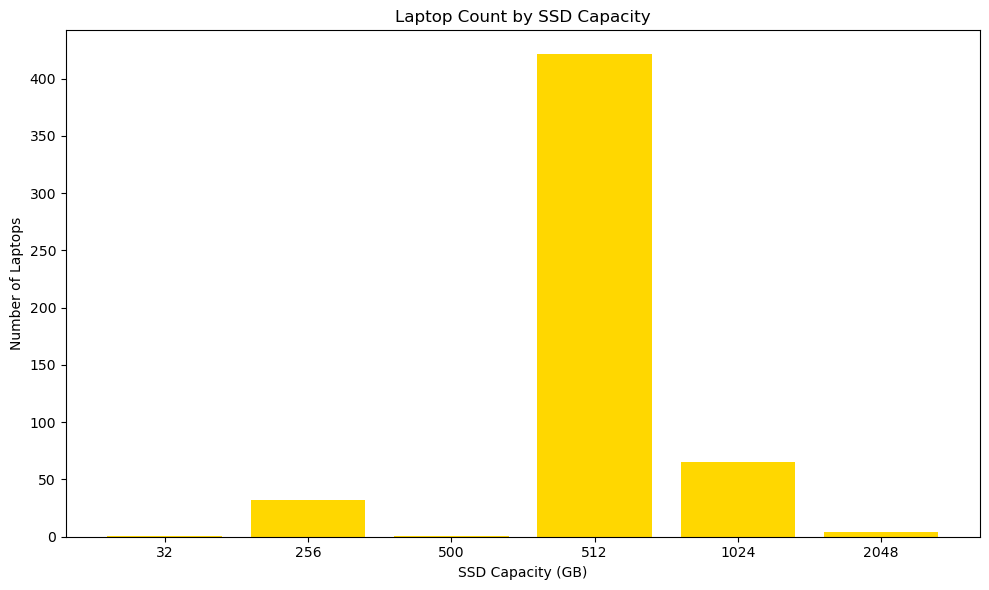

In [334]:
plt.figure(figsize=(10, 6))

plt.bar(ssd_counts.index.astype(str), ssd_counts.values,color='gold')

plt.title('Laptop Count by SSD Capacity')
plt.xlabel('SSD Capacity (GB)')
plt.ylabel('Number of Laptops')

plt.tight_layout()

plt.savefig('ssd_counts.png', transparent=True)

plt.show()

### Answer:

512 GB SSD is the most common configuration, with 421 laptops, followed by 1024 GB (1 TB) with 65 laptops and 256 GB with 32 laptops.

### Observation:

The dataset is strongly concentrated around 512 GB SSD, while higher capacities such as 1 TB and 2 TB have relatively fewer listings. Lower capacities such as 32 GB and 500 GB are rarely available.

### Question 5: Which brands offer the most expensive laptops on average?

In [338]:
#Bivariate Analysis
#Here we compare Brand with Price_rupee.

In [339]:
brand_avg_price = df.groupby('Brand')['Price_rupee'].mean().sort_values(ascending=False)
brand_avg_price

Brand
Apple         268576.666667
GIGABYTE      169645.000000
MICROSOFT     130136.000000
Samsung       116087.250000
MSI           102143.666667
Lenovo         88665.857143
ASUS           82863.853147
HP             77418.219858
MOTOROLA       74990.000000
Infinix        74367.250000
DELL           71097.058824
Acer           67162.135922
WINGS          59999.000000
Avita          56240.000000
Thomson        53990.000000
Ultimus        45990.000000
Prittec        35678.333333
WarnerCann     31943.500000
Primebook      27323.333333
Name: Price_rupee, dtype: float64

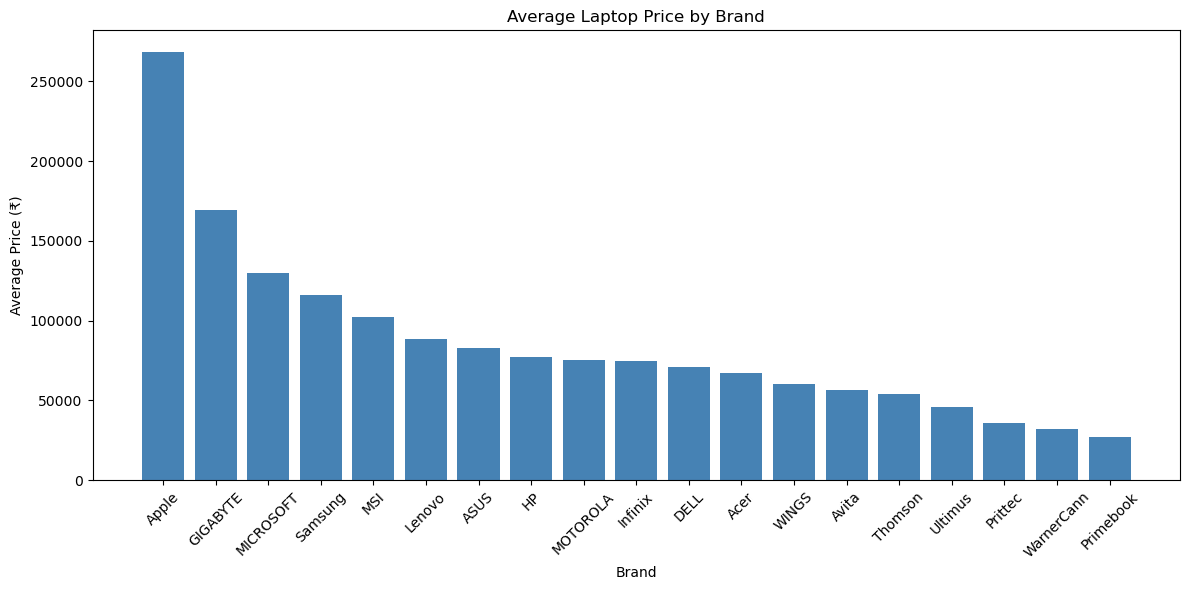

In [346]:
plt.figure(figsize=(12, 6))

plt.bar(brand_avg_price.index, brand_avg_price.values,color='steelblue')

plt.title('Average Laptop Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('brand_avg_price.png', transparent=True)

plt.show()

### Answer:

Apple has the highest average laptop price at approximately ₹2,68,577, followed by GIGABYTE at ₹1,69,645 and MICROSOFT at ₹1,30,136.

### Observation:

Apple stands out with a significantly higher average price than other brands, while GIGABYTE and MICROSOFT also have relatively high average prices. Brands such as Primebook, WarnerCann, and Prittec have much lower average prices.

### Question 6: Does higher RAM correspond to higher laptop prices?


In [347]:
# Analysis Type: Bivariate Analysis
# Here we compare RAM_gb with Price_rupee.

In [348]:
ram_avg_price = df.groupby('RAM_gb')['Price_rupee'].mean().sort_index()
ram_avg_price

RAM_gb
4      29964.526316
8      58734.857820
12     49147.583333
16     91663.670251
24    185752.500000
32    184558.809524
48    525900.000000
Name: Price_rupee, dtype: float64

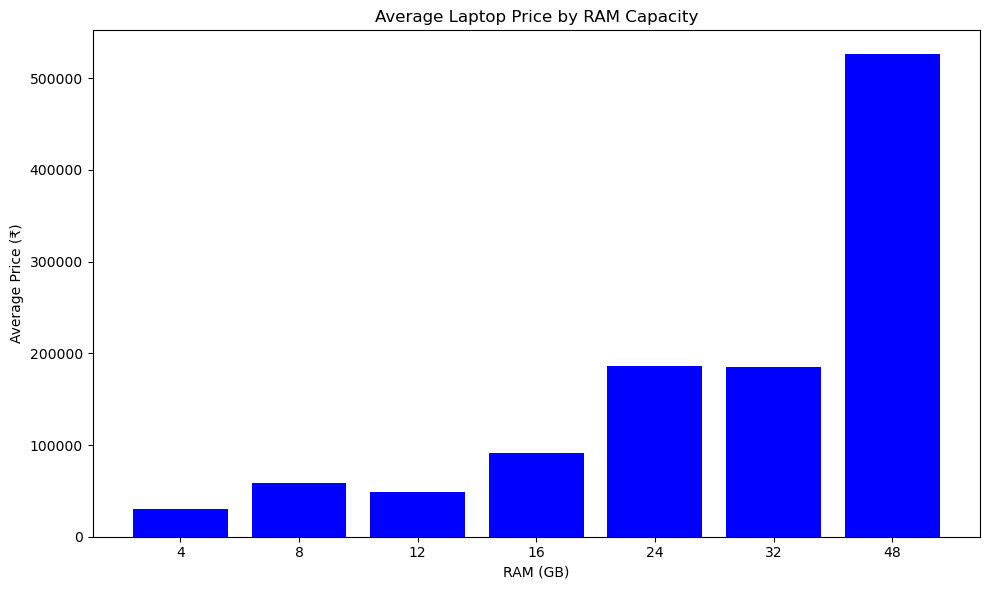

In [349]:
plt.figure(figsize=(10, 6))

plt.bar(ram_avg_price.index.astype(str), ram_avg_price.values, color='blue')

plt.title('Average Laptop Price by RAM Capacity')
plt.xlabel('RAM (GB)')
plt.ylabel('Average Price (₹)')

plt.tight_layout()

plt.savefig('ram_avg_price.png', transparent=True)

plt.show()

### Answer:
Yes, the average laptop price generally increases with higher RAM capacity. Laptops with 48 GB RAM have the highest average price at approximately ₹5,25,900, followed by 24 GB at ₹1,85,753 and 32 GB at ₹1,84,559.

### Observation:
Higher RAM configurations are generally associated with higher average laptop prices. The 48 GB category has a particularly high average price, while 4 GB and 8 GB laptops have much lower average prices.

### Question 7: Does higher SSD capacity correspond to higher laptop prices?

In [353]:
# Analysis Type: Bivariate Analysis
# We will compare SSD capacity with average laptop price.

In [354]:
ssd_avg_price = df.groupby('SSD_gb')['Price_rupee'].mean().sort_index()
ssd_avg_price

SSD_gb
32.0       29450.000000
256.0      46038.968750
500.0      41499.000000
512.0      75216.209026
1024.0    144307.153846
2048.0    418717.500000
Name: Price_rupee, dtype: float64

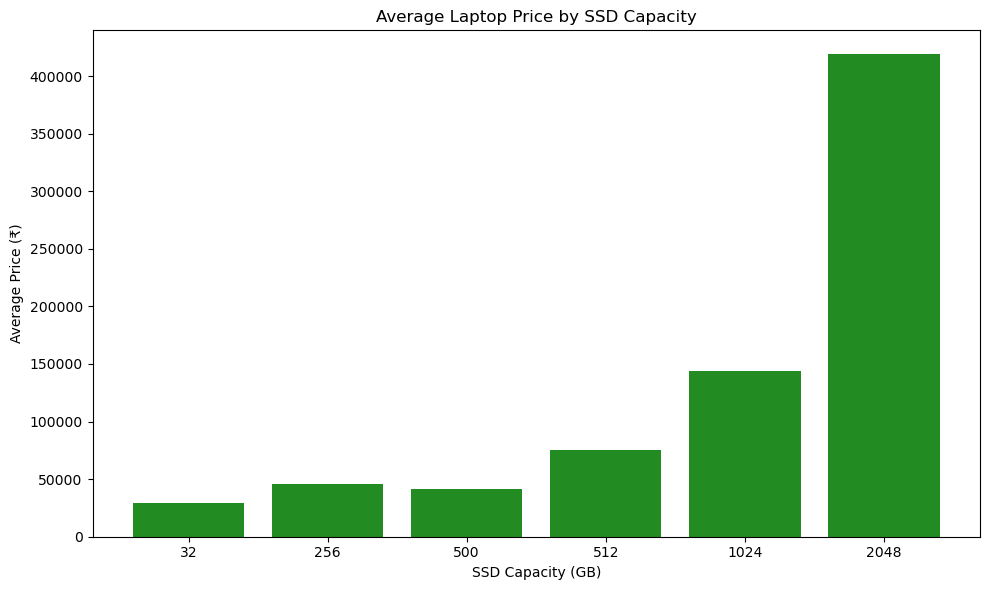

In [360]:
plt.figure(figsize=(10, 6))

plt.bar(ssd_avg_price.index.astype(int).astype(str), ssd_avg_price.values, color='forestgreen')

plt.title('Average Laptop Price by SSD Capacity')
plt.xlabel('SSD Capacity (GB)')
plt.ylabel('Average Price (₹)')

plt.tight_layout()

plt.savefig('ssd_avg_price.png', transparent=True)

plt.show()

### Answer:
Yes, higher SSD capacity generally corresponds to higher laptop prices. Laptops with 2048 GB (2 TB) SSD have the highest average price at approximately ₹4,18,718, followed by 1024 GB (1 TB) at ₹1,44,307 and 512 GB at ₹75,216.

### Observation:
The average laptop price generally increases as SSD capacity increases. The 2 TB category has a particularly high average price, while 256 GB and 32 GB laptops have much lower average prices.

### Question 8: Which processors are associated with higher average laptop prices?


In [361]:
# Analysis Type: Bivariate Analysis
# Here, we'll compare Processor with average Price_rupee.

In [362]:
processor_avg_price = df.groupby('Processor')['Price_rupee'].mean().sort_values(ascending=False)
processor_avg_price

Processor
Apple M5 Max                      619900.000000
Apple M5 Pro                      395900.000000
Intel Core Ultra 9                272995.000000
AMD Ryzen 9 Octa Core             227990.000000
AMD Ryzen 9 16 Core               220990.000000
Apple M5                          215445.000000
Intel Core Ultra X7               214990.000000
AMD Ryzen AI 7 Octa Core          169996.000000
Apple M3                          154900.000000
AMD Ryzen AI 9 12 Core            139899.000000
Intel Core Ultra 7                137422.055556
Intel Core i7                     135608.263158
Snapdragon X Plus                 130136.000000
Intel Core 7                      127247.333333
Intel Core i9                     119807.333333
Apple M2                          109900.000000
AMD Ryzen 7 Hexa Core             107945.000000
AMD Ryzen 7                       101997.000000
Intel Core Ultra 5                 91149.896552
Snapdragon Snapdragon X Elite      90990.000000
AMD Ryzen AI 5 Quad Core      

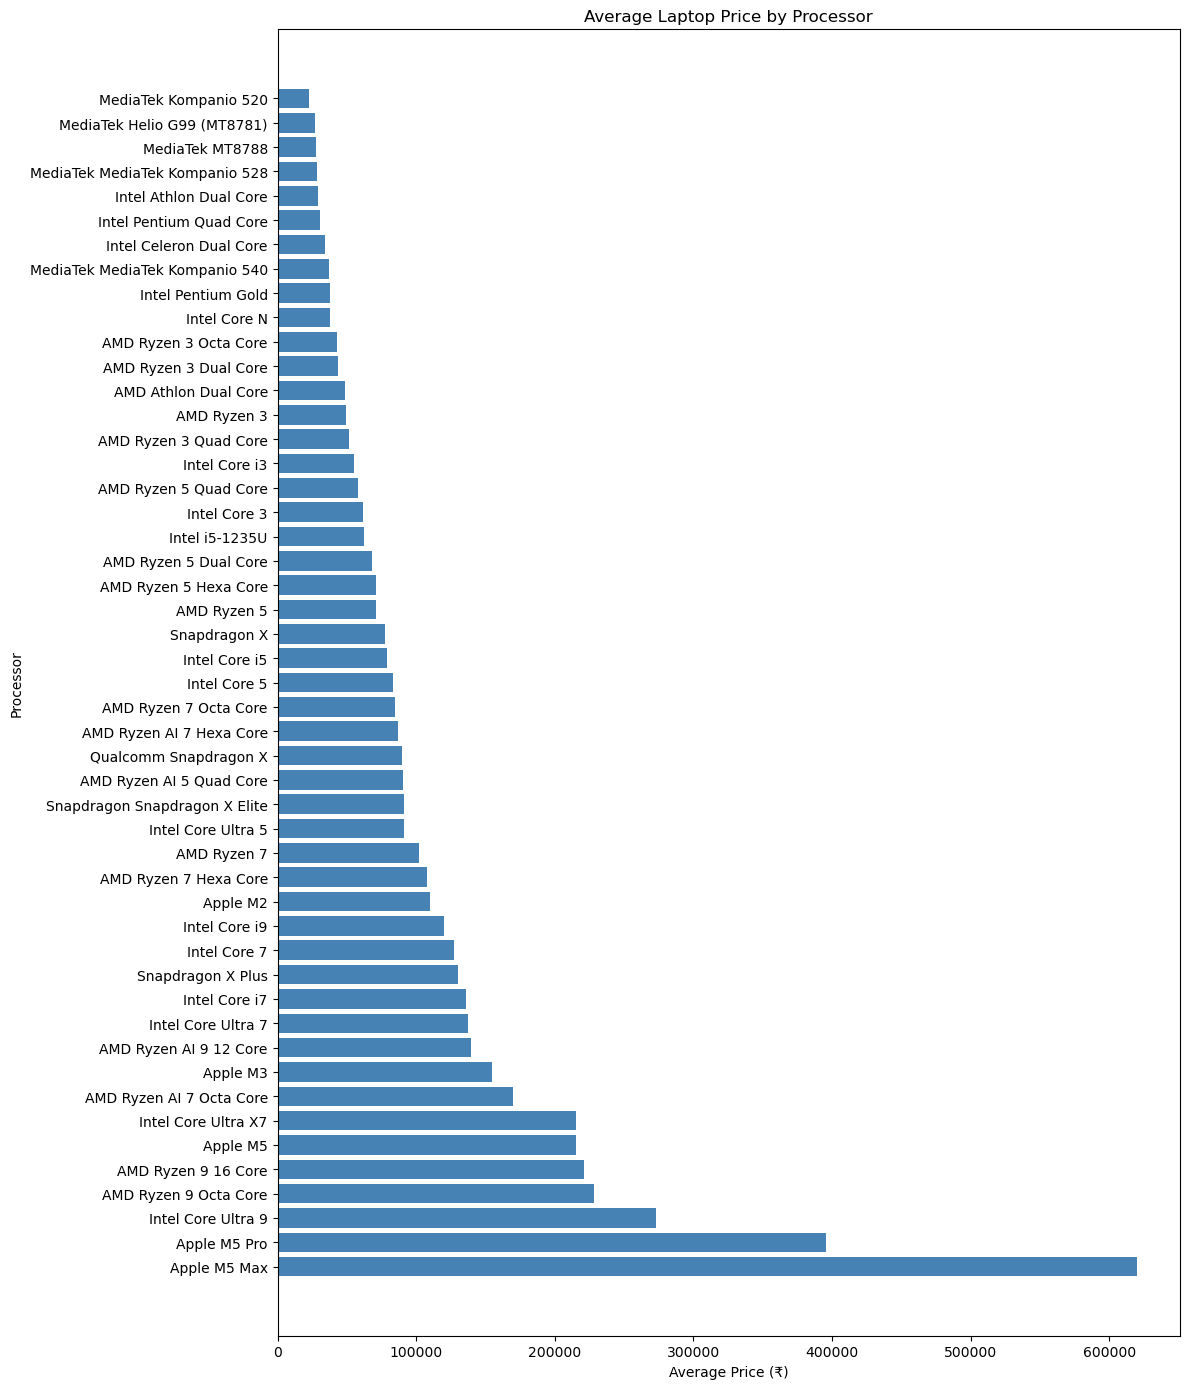

In [365]:
plt.figure(figsize=(12, 14))

plt.barh(processor_avg_price.index, processor_avg_price.values, color='steelblue')

plt.title('Average Laptop Price by Processor')
plt.xlabel('Average Price (₹)')
plt.ylabel('Processor')

plt.tight_layout()

plt.savefig('processor_avg_price.png', transparent=True)

plt.show()

### Answer:
Apple M5 Max processors are associated with the highest average laptop price at approximately ₹6,19,900, followed by Apple M5 Pro at ₹3,95,900 and Intel Core Ultra 9 at ₹2,72,995.

### Observation:
Premium processors such as Apple M5 Max, Apple M5 Pro, Intel Core Ultra 9, and AMD Ryzen 9 are associated with much higher average laptop prices, while entry-level processors such as MediaTek, Intel Celeron, and Intel Pentium have lower average prices.

### Question 9 : What combination of Brand, RAM and SSD is associated with premium laptop pricing?

In [ ]:
# Analysis Type: Multivariate Analysis
# Here we will examine three variables together:

In [378]:
brand_ram_ssd_price = df.groupby(['Brand', 'RAM_gb', 'SSD_gb'])['Price_rupee'].mean().sort_values(ascending=False)
#Top 15 combinations with the highest average price are taking as we have 71.
top_15_combinations = brand_ram_ssd_price.head(15)
top_15_combinations

Brand     RAM_gb  SSD_gb
Apple     48      2048.0    619900.000000
ASUS      32      2048.0    489990.000000
Apple     48      1024.0    431900.000000
          24      1024.0    359900.000000
          32      1024.0    287900.000000
MSI       32      2048.0    282490.000000
Samsung   32      1024.0    212139.500000
Lenovo    32      1024.0    199495.000000
ASUS      32      1024.0    192527.000000
Apple     16      1024.0    174900.000000
Lenovo    16      1024.0    171292.000000
GIGABYTE  16      512.0     169645.000000
HP        24      1024.0    166575.333333
          32      1024.0    160689.000000
Apple     16      512.0     142990.000000
Name: Price_rupee, dtype: float64

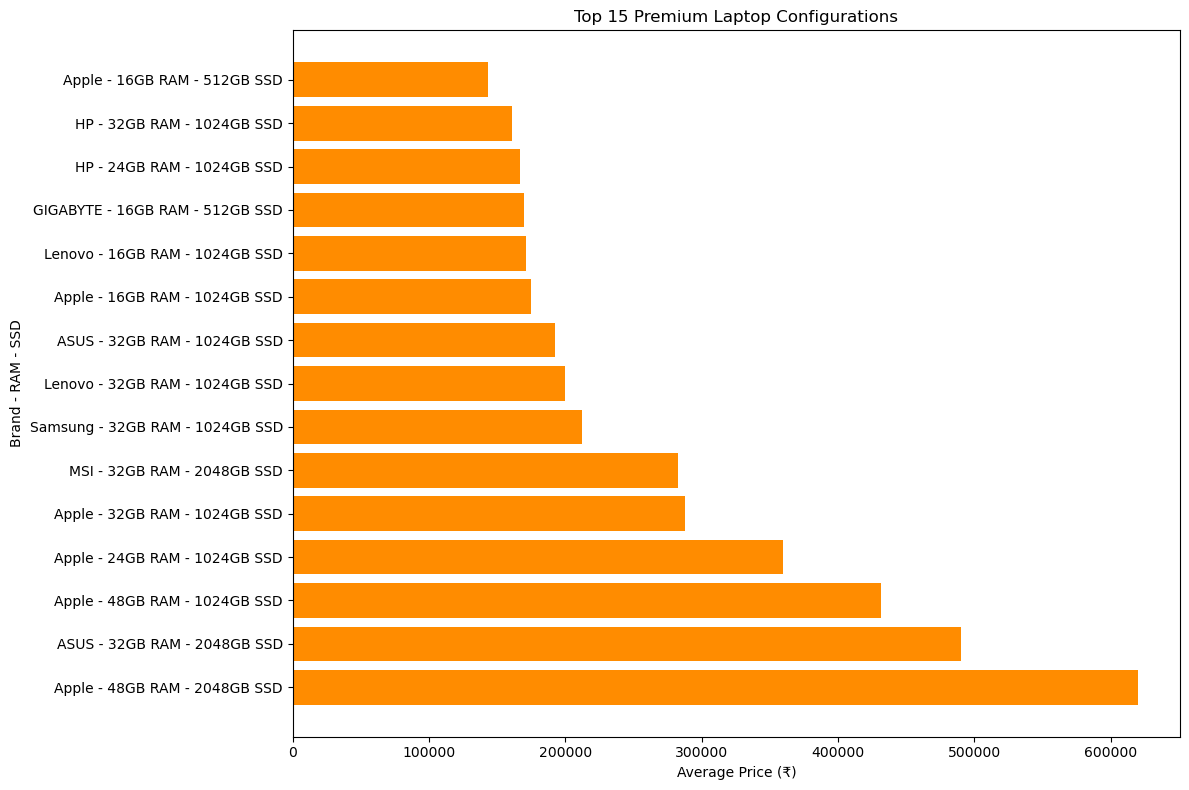

In [387]:


labels = [
    f"{brand} - {ram}GB RAM - {ssd:.0f}GB SSD"
    for brand, ram, ssd in top_15_combinations.index
]

plt.figure(figsize=(12, 8))

plt.barh(labels, top_15_combinations.values, color='darkorange')

plt.title('Top 15 Premium Laptop Configurations')
plt.xlabel('Average Price (₹)')
plt.ylabel('Brand - RAM - SSD')

plt.tight_layout()

plt.savefig('premium_configurations.png', transparent=True)

plt.show()

### Answer:
Apple laptops with higher RAM and SSD capacities are associated with the highest premium prices. The highest-priced combination is Apple with 48 GB RAM and 2048 GB SSD, averaging ₹6,19,900, followed by ASUS with 32 GB RAM and 2048 GB SSD at ₹4,89,990.

### Observation:
Premium-priced laptops are generally associated with higher RAM and SSD configurations. Apple dominates the highest-priced combinations, while ASUS, MSI, Samsung, and Lenovo also appear among the higher-priced configurations.

### Question 10: Which brands dominate the premium laptop segment?

In [395]:
#Analysis Type: Bivariate Analysis

In [389]:
#1.Create the premium laptop dataset ---- means Premium laptops = laptops priced above ₹1,00,000

In [393]:
premium_laptops = df[df['Price_rupee'] > 100000]

premium_brand_counts = premium_laptops['Brand'].value_counts()
premium_brand_counts

Brand
HP           23
ASUS         21
Lenovo       15
Apple         9
Acer          9
MSI           8
Samsung       3
GIGABYTE      2
MICROSOFT     2
DELL          1
Name: count, dtype: int64

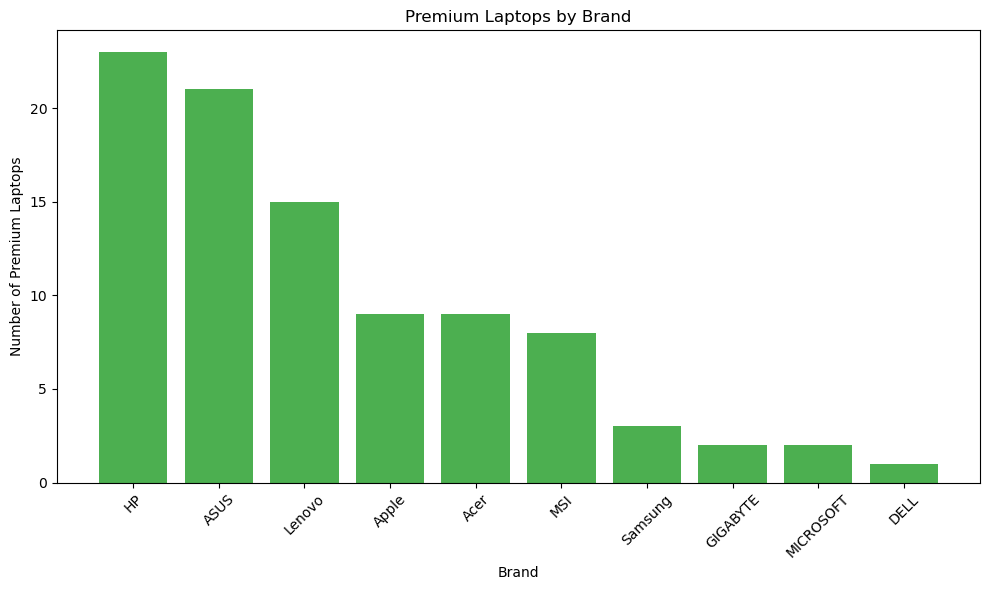

In [394]:
plt.figure(figsize=(10, 6))

plt.bar(premium_brand_counts.index, premium_brand_counts.values, color='#4CAF50')

plt.title('Premium Laptops by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Premium Laptops')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('premium_brand_counts.png', transparent=True)

plt.show()

### Answer:
HP dominates the premium laptop segment, with 23 laptops priced above ₹1,00,000, followed by ASUS with 21 and Lenovo with 15. Apple and Acer each have 9 premium laptops.

### Observation:
HP and ASUS have the largest number of premium laptops in the scraped dataset, while Lenovo also has a strong presence. Apple has fewer premium listings by count, but its average laptop price is substantially higher, as seen in Question 5.

## Recommendations

- Prioritize 8 GB and 16 GB RAM laptops for mainstream customers.
- Maintain strong inventory of 512 GB SSD laptops and offer 1 TB/2 TB as premium alternatives.
- Maintain premium offerings from HP, ASUS and Lenovo while positioning Apple for higher-budget customers.
- Use higher RAM and SSD configurations to create premium offerings and upselling opportunities.
- Maintain a balanced portfolio covering high-demand mainstream brands and higher-specification premium models.
